
---

## A. Monte Carlo Integration 

Student number: u2012113

Consider the integral

$$
\int_a^b f(x) \, dx
$$

where $f(x) = \sin(x^2)$, $a=0$ and $b = \sqrt{2\pi}$. As noted [here](https://en.wikipedia.org/wiki/Nonelementary_integral), $\sin(x^2)$ does not have an elementary antiderivative so we use numerical methods to evaluate this integral.


The first method is to use the fact that the mean average of $f$ over the interval [0,$\sqrt{2\pi}$], is 
$$
\bar f = \frac{1}{\sqrt{2\pi}} \int_0^ \sqrt{2\pi} f(x) \, dx
$$
We can generate a random sample of points $x$ on $[0,\sqrt{2\pi}]$ using Monte Carlo and evaluate $f(x)$ at each of these points and compute the mean. This gives our approximation to $\bar f$. Multiplying by $\sqrt{2\pi}$ we get the approximation to the integral. Then, we ccan plot a rectangle which area is the integral we want to solve. The code computes and plots the function $f(x) = \sin(x^2)$ and this rectangle.


The second method is to use Monte Carlo with $N=2000$ sample points over a rectangle $[0,\sqrt{2\pi}] \times [-1,1]$. The graph of $y = f(x)$ partitions the rectangle into three regions. We can then colour the points according to the region they are in. Using the fact that the integral is the signed area under the curve, we can estimate the area of these regions and estimate the integral which we expect it to be the signed area under the curve satisfying
$$
\frac{\text{Number of  'signed' points under curve}}{\text{N}} \simeq 
\frac{\text{'Signed' area under curve}}{\text{Area of rectangle}} 
$$

In addition, the average colour of the points in the second graph is plotted into a square.

Method 2 sometimes does not give very accurate results, but this can be solved by increasing N, although it will take more time to plot the figure.


---

In [1]:
# import libraries

import numpy as np
import matplotlib.pyplot as plt

The Monte Carlo estimate for the integral is 0.4326313534013642


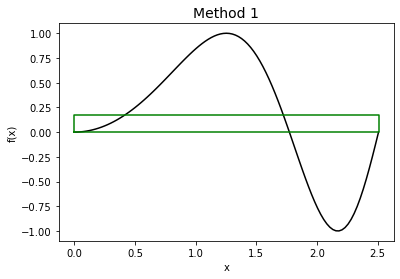

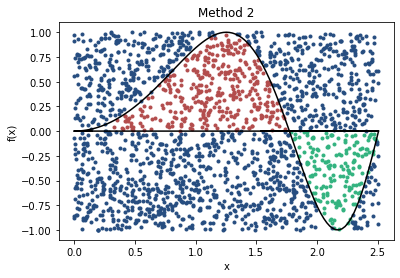

The signed area under the curve is: 0.468739487355997



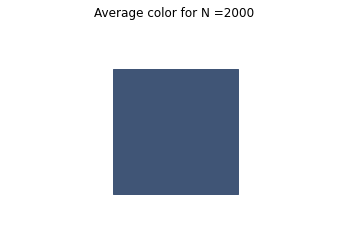

In [2]:
# --- Method 1-- #

# define the function to integrate
def my_fun(x):
    return np.sin(x**2)

# set the interval [a,b] and the number of samples
a, b = 0, (2*np.pi)**(0.5)
N = 10**6

# generate the samples and evaluate f at each 
x = np.random.uniform(a, b, N)
f_of_x = my_fun(x)

# compute the mean and estimate the integral
f_mean = np.mean(f_of_x)
my_integral = (b-a) * f_mean
print("The Monte Carlo estimate for the integral is", my_integral)

# plot the function and sample points
x_plot = np.linspace(a,b,101)
y_plot = my_fun(x_plot)
plt.plot(x_plot,y_plot, 'black')
plt.plot([a,b,b,a,a],[0,0,f_mean,f_mean,0],'g')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Method 1', fontsize = 14)
plt.show()

# --- Method 2 --- #
print()

# generate N random numbers in a rectangle [0,√2𝜋]x[-1,1]
N = 2000
x = np.random.uniform(0, (2*np.pi)**(0.5), N)
y = np.random.uniform(-1,1,N)
y_0 = np.zeros(N)


# plot coloured points depending on the region
t_1 = 0
t_2 = 0
t_3 = 0

for i in range(N):
    if 0<=y[i]<=my_fun(x[i]):
        R1,G1,B1 = 0.7, 0.3, 0.3
        plt.plot(x[i],y[i], '.', color = (R1,G1,B1))
        t_1+=1
    elif 0>=y[i]>= my_fun(x[i]) :
        R2,G2,B2 = 0.2, 0.7, 0.5
        plt.plot(x[i],y[i], '.',color = (R2,G2,B2))
        
        t_2+=1
    else:
        R3,G3,B3 = 0.15, 0.3, 0.5
        plt.plot(x[i],y[i],'.', color = (R3,G3,B3))
        t_3 += 1
        
# plot the function 
plt.plot(x_plot,y_plot,'black')
plt.plot(x,y_0,'black')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Method 2')
plt.show()

print("The signed area under the curve is: " + str(2*(2*np.pi)**(0.5)*(t_1-t_2)/N))
print()


R,G,B = (R1*t_1+R2*t_2+R3*t_3)/N, (G1*t_1+G2*t_2+G3*t_3)/N, (B1*t_1+B2*t_2+B3*t_3)/N

plt.plot(0.5, 0.5, 's', markersize=125, color = (R,G,B))
plt.axis('off')
plt.title("Average color for N ="+ str(N))
plt.show()

